In [310]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("data\\laptop_price.csv", encoding="latin-1")

In [312]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [313]:
df.shape

(1303, 13)

In [314]:
df.dtypes

laptop_ID             int64
Company              object
Product              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price_euros         float64
dtype: object

In [315]:
df["Company"].value_counts()

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64

In [316]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [317]:
df["Weight"] = df["Weight"].str.replace("kg","")

In [318]:
df["Weight"] = df["Weight"].astype('float64')

In [319]:
df["ScreenResolution"] = df["ScreenResolution"].str.split().str[-1].str.replace("x", " ")

In [320]:
df["Screen width"] = df["ScreenResolution"].str.split().str[0]
df["Screen height"] = df["ScreenResolution"].str.split().str[1]

In [321]:
df = df.drop(columns=["ScreenResolution"])

In [322]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Screen width,Screen height
0,1,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,2560,1600
1,2,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,1440,900
2,3,HP,250 G6,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00,1920,1080
3,4,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,2880,1800
4,5,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60,2560,1600


In [323]:
df = df.rename(columns={'Screen width': 'Screen_width', 'Screen height': 'Screen_height'})

In [324]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Screen_width,Screen_height
0,1,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,2560,1600
1,2,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,1440,900
2,3,HP,250 G6,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00,1920,1080
3,4,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,2880,1800
4,5,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60,2560,1600


In [325]:
# Get value counts and filter for counts > 20, then get the index (CPU names)
cpu_names = df['Cpu'].value_counts()[df['Cpu'].value_counts() < 15].index.tolist()

# Or step by step:
value_counts = df['Cpu'].value_counts()
cpu_names = value_counts[value_counts <15].index.tolist()

print("CPU names with count < 20:")
print(cpu_names)
print(len(cpu_names))

CPU names with count < 20:
['Intel Pentium Quad Core N4200 1.1GHz', 'Intel Core i5 7300U 2.6GHz', 'Intel Core i7 7600U 2.8GHz', 'Intel Pentium Quad Core N3710 1.6GHz', 'AMD A9-Series 9420 3GHz', 'Intel Core i5 6300U 2.4GHz', 'Intel Celeron Dual Core N3050 1.6GHz', 'Intel Core i7 6820HK 2.7GHz', 'Intel Core i3 6100U 2.3GHz', 'Intel Core i3 7130U 2.7GHz', 'Intel Core i7 6820HQ 2.7GHz', 'Intel Core i5 6300HQ 2.3GHz', 'Intel Core i7 7820HK 2.9GHz', 'AMD A6-Series 9220 2.5GHz', 'Intel Core i7 7820HQ 2.9GHz', 'Intel Core M 6Y75 1.2GHz', 'Intel Atom x5-Z8350 1.44GHz', 'AMD A12-Series 9720P 3.6GHz', 'Intel Celeron Quad Core N3450 1.1GHz', 'Intel Core i7 7Y75 1.3GHz', 'Intel Core i5 7440HQ 2.8GHz', 'AMD A8-Series 7410 2.2GHz', 'Intel Celeron Dual Core 3205U 1.5GHz', 'Intel Atom x5-Z8550 1.44GHz', 'Intel Celeron Dual Core 3855U 1.6GHz', 'Intel Core i7 7660U 2.5GHz', 'Intel Core M 6Y30 0.9GHz', 'AMD A9-Series 9410 2.9GHz', 'AMD Ryzen 1700 3GHz', 'Intel Core i5 1.6GHz', 'Intel Core i5 7Y54 1.2GHz'

In [326]:
df[df["Cpu"] == "Intel Core i3 6006U 2.0GHz"].value_counts().sum()

np.int64(16)

In [327]:
for i in cpu_names:

    print(int(df[df["Cpu"] == i].value_counts().sum()))

14
14
13
11
11
11
11
10
9
8
7
7
7
7
5
5


5
5
5
5
5
4
4
4
3
3
3
3
3
3
3
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


In [328]:
sum = 0
for i in cpu_names:

    sum+=int(df[df["Cpu"] == i].value_counts().sum())

In [329]:
sum

302

In [330]:
df.shape

(1303, 14)

In [331]:
sum/df.shape[0]

0.23177283192632386

In [332]:
df["Cpu"] = df["Cpu"].str.split().str[:-1].str.join(" ")

In [333]:
df.head() 

,laptop_ID,Company,Product,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Screen_width,Screen_height
0,1,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,2560,1600
1,2,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,1440,900
2,3,HP,250 G6,Notebook,15.6,Intel Core i5 7200U,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00,1920,1080
3,4,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,2880,1800
4,5,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60,2560,1600


In [334]:
df["Cpu"].value_counts()

Cpu
Intel Core i5 7200U     193
Intel Core i7 7700HQ    147
Intel Core i7 7500U     135
Intel Core i3 6006U      81
Intel Core i7 8550U      73
                       ... 
AMD FX 9830P              1
Intel Core i5 6440HQ      1
AMD E-Series E2-6110      1
AMD Ryzen 1600            1
Intel Core i7 6920HQ      1
Name: count, Length: 93, dtype: int64

In [335]:
req = ["i5", "i7", "i3"]

In [336]:
req = ["i5", "i7", "i3"]

last_word = df["Cpu"].str.split().str[-1]

df["Cpu"] = np.where(
    last_word.isin(req),
    df["Cpu"],
    df["Cpu"].str.split().str[:-1].str.join(" ")
)

In [337]:
df["Cpu"].value_counts()

Cpu
Intel Core i7              527
Intel Core i5              423
Intel Core i3              136
Intel Celeron Dual Core     80
Intel Pentium Quad Core     27
AMD A9-Series               17
Intel Core M                15
Intel Atom                  13
AMD A6-Series               11
AMD E-Series                 9
AMD A12-Series               8
Intel Celeron Quad Core      8
AMD A10-Series               6
AMD Ryzen                    4
Intel Core                   4
AMD A8-Series                4
Intel Pentium Dual Core      3
AMD FX                       2
Intel Xeon E3-1535M          2
Intel Xeon E3-1505M          2
AMD A4-Series                1
Samsung Cortex               1
Name: count, dtype: int64

In [338]:
# Define the allowed values
allowed_cpus = ['Intel Core i7', 'Intel Core i5', 'Intel Core i3','Intel Celeron Dual Core','Intel Pentium Quad Core']

# Keep only rows where Cpu is in the allowed list
df = df[df['Cpu'].isin(allowed_cpus)]

In [339]:
df["Cpu"].value_counts()

Cpu
Intel Core i7              527
Intel Core i5              423
Intel Core i3              136
Intel Celeron Dual Core     80
Intel Pentium Quad Core     27
Name: count, dtype: int64

In [340]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Screen_width,Screen_height
0,1,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,2560,1600
1,2,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,1440,900
2,3,HP,250 G6,Notebook,15.6,Intel Core i5,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00,1920,1080
3,4,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,2880,1800
4,5,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60,2560,1600


In [341]:
df.dtypes

laptop_ID          int64
Company           object
Product           object
TypeName          object
Inches           float64
Cpu               object
Ram               object
Memory            object
Gpu               object
OpSys             object
Weight           float64
Price_euros      float64
Screen_width      object
Screen_height     object
dtype: object

In [342]:
df["Screen_width"] = df["Screen_width"].astype("float64")

In [343]:

df["Screen_height"] = df["Screen_height"].astype("float64")

In [344]:
df.dtypes

laptop_ID          int64
Company           object
Product           object
TypeName          object
Inches           float64
Cpu               object
Ram               object
Memory            object
Gpu               object
OpSys             object
Weight           float64
Price_euros      float64
Screen_width     float64
Screen_height    float64
dtype: object

In [345]:
numeric_features = [features for features in df.columns if df[features].dtype !='O']
categorical_features =[features for features in df.columns if df[features].dtype =='O']

In [346]:
numeric_features

['laptop_ID',
 'Inches',
 'Weight',
 'Price_euros',
 'Screen_width',
 'Screen_height']

In [347]:
categorical_features

['Company', 'Product', 'TypeName', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys']

In [348]:
df["Memory"].value_counts()
allowed_memory = [
    "256GB SSD","1TB HDD","500GB HDD","512GB SSD","128GB SSD +  1TB HDD", "256GB SSD +  1TB HDD","128GB SSD", "32GB Flash Storage"
]

In [349]:
df["Memory"].value_counts()

Memory
256GB SSD                    396
1TB HDD                      208
500GB HDD                    119
512GB SSD                    110
128GB SSD +  1TB HDD          92
256GB SSD +  1TB HDD          68
128GB SSD                     65
32GB Flash Storage            28
512GB SSD +  1TB HDD          13
1TB SSD                       13
2TB HDD                       12
256GB SSD +  2TB HDD          10
16GB Flash Storage             6
256GB Flash Storage            6
1.0TB Hybrid                   6
64GB Flash Storage             6
180GB SSD                      5
128GB Flash Storage            4
16GB SSD                       3
32GB SSD                       3
512GB SSD +  2TB HDD           3
1TB SSD +  1TB HDD             2
256GB SSD +  256GB SSD         2
128GB SSD +  2TB HDD           2
256GB SSD +  500GB HDD         2
512GB SSD +  256GB SSD         1
512GB SSD +  512GB SSD         1
1TB HDD +  1TB HDD             1
128GB HDD                      1
8GB SSD                        1
508

In [350]:
df= df[df["Memory"].isin(allowed_memory)]

In [351]:
df["Memory"].value_counts()

Memory
256GB SSD               396
1TB HDD                 208
500GB HDD               119
512GB SSD               110
128GB SSD +  1TB HDD     92
256GB SSD +  1TB HDD     68
128GB SSD                65
32GB Flash Storage       28
Name: count, dtype: int64

## Exploratory Data Analysis

In [352]:
df.shape

(1086, 14)

In [353]:
df["Ram"] = df["Ram"].str.replace("GB","")

In [354]:
df["Ram"] = df["Ram"].astype("float64")

In [355]:
df.dtypes

laptop_ID          int64
Company           object
Product           object
TypeName          object
Inches           float64
Cpu               object
Ram              float64
Memory            object
Gpu               object
OpSys             object
Weight           float64
Price_euros      float64
Screen_width     float64
Screen_height    float64
dtype: object

In [361]:
df["OpSys"].value_counts()

OpSys
Windows 10      901
Linux            61
No OS            59
Windows 7        40
macOS            10
Chrome OS        10
Windows 10 S      5
Name: count, dtype: int64

In [357]:
df = df.drop(columns = ["laptop_ID","Product","Gpu"])

In [358]:
numeric_features = [features for features in df.columns if df[features].dtype !='O' and features != "laptop_ID"]
categorical_features =[features for features in df.columns if df[features].dtype =='O']

print(numeric_features)
print(categorical_features)

['Inches', 'Ram', 'Weight', 'Price_euros', 'Screen_width', 'Screen_height']
['Company', 'TypeName', 'Cpu', 'Memory', 'OpSys']


## Exploratory Data Analysis

In [362]:
print("Categories in 'Company' variable:      ",end=" ")
print(df['Company'].unique())

print("Categories in 'TypeName' variable: ", end = " ")
print(df["TypeName"].unique())
print("Categories in 'Cpu' variable: ", end = " ")
print(df["Cpu"].unique())

print("Categories in 'Memory' variable: ", end = " ")
print(df["Memory"].unique())

print("Categories in 'OpSys' variable:      ", end = " ")
print(df["OpSys"].unique())

Categories in 'Company' variable:       ['Apple' 'HP' 'Asus' 'Acer' 'Dell' 'Lenovo' 'Microsoft' 'MSI' 'Toshiba'
 'Huawei' 'Xiaomi' 'Vero' 'Google' 'Fujitsu' 'Samsung' 'Razer' 'LG']
Categories in 'TypeName' variable:  ['Ultrabook' 'Notebook' 'Gaming' '2 in 1 Convertible' 'Workstation'
 'Netbook']
Categories in 'Cpu' variable:  ['Intel Core i5' 'Intel Core i7' 'Intel Core i3' 'Intel Pentium Quad Core'
 'Intel Celeron Dual Core']
Categories in 'Memory' variable:  ['128GB SSD' '256GB SSD' '512GB SSD' '500GB HDD' '1TB HDD'
 '128GB SSD +  1TB HDD' '256GB SSD +  1TB HDD' '32GB Flash Storage']
Categories in 'OpSys' variable:       ['macOS' 'No OS' 'Windows 10' 'Linux' 'Windows 10 S' 'Chrome OS'
 'Windows 7']


### Exploring Data(Visualization)

In [364]:
numeric_features

['Inches', 'Ram', 'Weight', 'Price_euros', 'Screen_width', 'Screen_height']

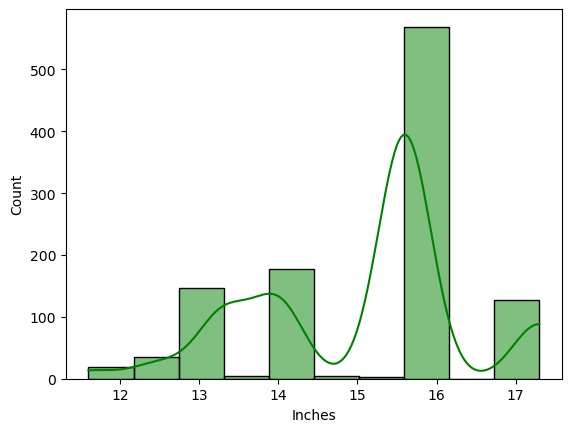

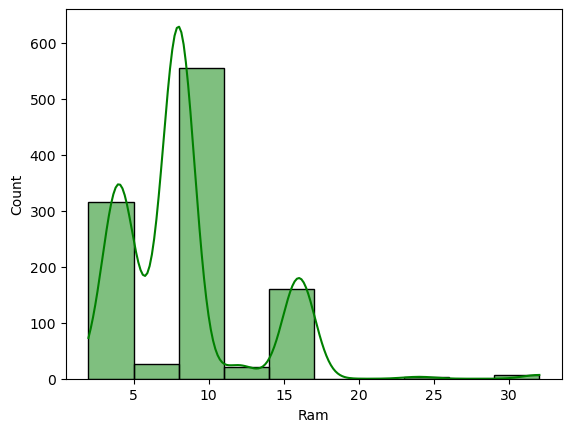

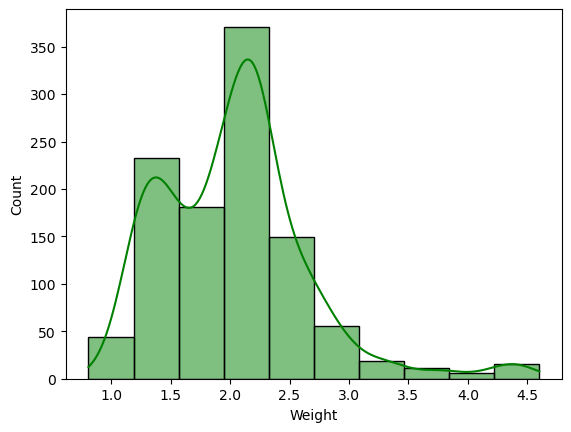

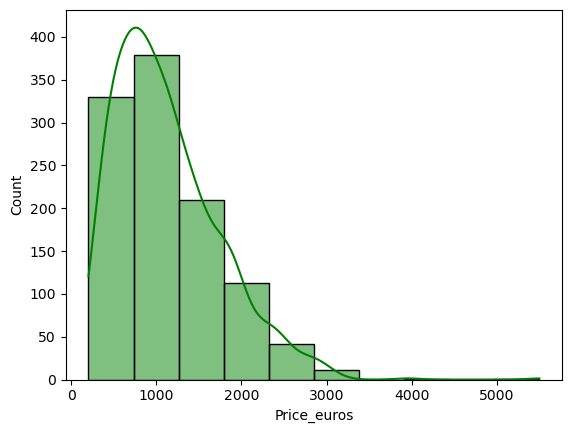

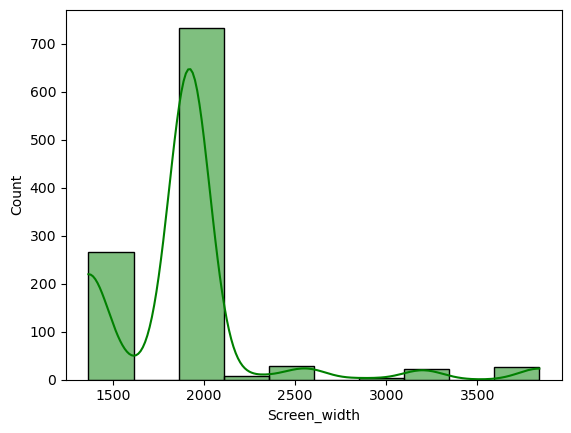

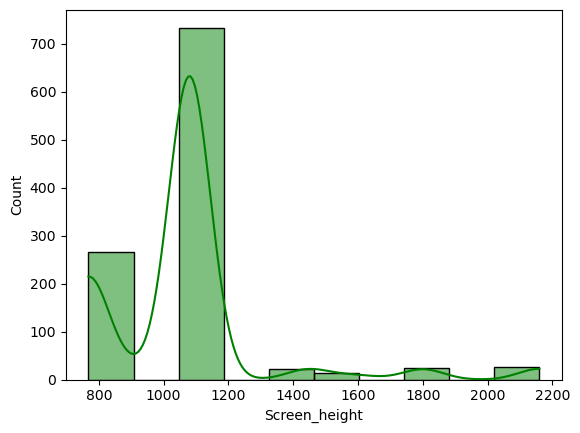

In [367]:

for i in numeric_features:
    plt.plot(figsize=(15,7))
    sns.histplot(data=df, x= i, bins = 10 , kde=True, color='g')
    plt.show()

In [368]:
import os 

folder_path = 'C:\\Users\\Zukisa\\Downloads\\End to End Machine Learning(Laptop Price)\\notebooks\\data'
file_name = "laptop_price_edited.csv"
full_path = os.path.join(folder_path, file_name)
df.to_csv(full_path,index= False)